#AI DISASTER RESPONSE COORDINATOR - A Multimodal AI System for Emergency Prioritisation

## Prototype Scenarios

This prototype demonstrates a multimodal AI disaster response decision-support system for three simulated emergency scenarios:

| Scenario      | Audio Input    | Image Input      | Manual Report              | AI Models Used             |
| ------------- | -------------- | ----------------- | --------------------------- | --------------------------- |
| Flood      | Emergency call | Flood image      | Flood incident report      | Whisper → BLIP → Qwen2.5-1.5B |
| Fire       | Emergency call | Fire image       | Fire incident report       | Whisper → BLIP → Qwen2.5-1.5B |
| Earthquake | Emergency call | Earthquake image | Earthquake incident report | Whisper → BLIP → Qwen2.5-1.5B |

### Workflow

For each disaster scenario, the prototype performs the following steps:

1. Converts emergency audio into text using **Whisper**.
2. Analyses the disaster image using **BLIP**.
3. Combines the audio transcript, image caption, and manual incident report.
4. Generates a structured emergency assessment using **Qwen2.5-1.5B**, including:

   * Incident Summary
   * Severity Level
   * Priority Recommendation
   * Reasoning

In [1]:
!pip install -q transformers sentencepiece accelerate torch

In [2]:
import torch

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

GPU available: False


In [3]:
# ===== CONFIGURATION =====
# Centralised model names and generation settings.

WHISPER_MODEL_SIZE = "base"

# Qwen2.5-1.5B-Instruct replaced the originally planned TinyLlama-1.1B-Chat.
# Evaluation showed TinyLlama could not reliably follow the required
# four-field output format (see Evaluation chapter). Qwen was tested as
# a stronger alternative under the same pipeline and validation rules.
LLM_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
BLIP_MODEL_NAME = "Salesforce/blip-image-captioning-base"

# Settings used for the first (main) generation attempt.
# do_sample=False keeps generation deterministic, so the same incident
# evidence always produces the same output - important for a fair,
# repeatable evaluation across test cases.
# repetition_penalty and no_repeat_ngram_size reduce the small model's
# tendency to repeat phrases, which was observed during testing.
GENERATION_CONFIG = {
    "max_new_tokens": 220,
    "do_sample": False,
    "repetition_penalty": 1.15,
    "no_repeat_ngram_size": 3,
}

# Shorter, stricter settings used only for the retry attempt
RETRY_GENERATION_CONFIG = {
    "max_new_tokens": 120,
    "do_sample": False,
    "repetition_penalty": 1.15,
    "no_repeat_ngram_size": 3,
}

print("Configuration loaded successfully.")

Configuration loaded successfully.


In [4]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 11.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 2.6 MB/s eta 0:00:00


In [5]:
!pip install -q gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.


##Flood scenario

## Early Prototyping and Model Exploration

The cells below (Whisper test, BLIP test, and several early prompt attempts) were used
to explore how each individual model behaved before the final pipeline was built.

They are kept here for transparency, to show the iterative development process,
but they are **not part of the final system**. The final, reusable implementation
starts at the "Final Pipeline Implementation" section below.

In [6]:
from gtts import gTTS

emergency_script = """
There has been severe flooding near the main road.
Two people are trapped inside a vehicle.
Water levels are rising quickly and rescue support is urgently needed.
"""

tts = gTTS(emergency_script)
tts.save("emergency_audio.mp3")

print("Emergency audio file created successfully.")

Emergency audio file created successfully.


In [ ]:
from IPython.display import Audio

Audio("emergency_audio.mp3")

In [7]:
import whisper

model = whisper.load_model(WHISPER_MODEL_SIZE)

print("Whisper model loaded successfully")

100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 124MiB/s]


Whisper model loaded successfully


In [ ]:
result = model.transcribe("emergency_audio.mp3")

print(result["text"])

 There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.


In [ ]:
# WHISPER MODEL SIZE COMPARISON

import time
import pandas as pd

whisper_comparison_results = []

for size in ["tiny", "base", "small"]:
    print(f"Loading Whisper '{size}'...")

    start_load = time.time()
    comparison_model = whisper.load_model(size)
    load_time = time.time() - start_load

    start_transcribe = time.time()
    comparison_result = comparison_model.transcribe("emergency_audio.mp3")
    transcribe_time = time.time() - start_transcribe

    whisper_comparison_results.append({
        "Model Size": size,
        "Transcript": comparison_result["text"].strip(),
        "Load Time (s)": round(load_time, 2),
        "Transcribe Time (s)": round(transcribe_time, 2)
    })

    # Free memory before loading the next model size
    del comparison_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

whisper_comparison_df = pd.DataFrame(whisper_comparison_results)

print("\n===== WHISPER MODEL SIZE COMPARISON =====")
display(whisper_comparison_df)

Loading Whisper 'tiny'...


100%|█████████████████████████████████████| 72.1M/72.1M [00:01<00:00, 65.7MiB/s]


Loading Whisper 'base'...
Loading Whisper 'small'...


100%|███████████████████████████████████████| 461M/461M [00:08<00:00, 58.8MiB/s]



===== WHISPER MODEL SIZE COMPARISON =====


,Model Size,Transcript,Load Time (s),Transcribe Time (s)
0,tiny,There has been severe flooding near the main r...,4.10,0.98
1,base,There has been severe flooding near the main r...,2.28,0.81
2,small,There has been severe flooding near the main r...,13.25,0.85


In [ ]:
for row in whisper_comparison_results:
    print(f"--- {row['Model Size']} ---")
    print(row["Transcript"])
    print()

--- tiny ---
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

--- base ---
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

--- small ---
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.



In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

llm_tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL_NAME)
llm_model = AutoModelForCausalLM.from_pretrained(
    LLM_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Qwen2.5-1.5B-Instruct loaded successfully")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2.5-1.5B-Instruct loaded successfully


In [9]:
from PIL import Image

In [ ]:
incident_report = result["text"]

prompt = f"""
You are an emergency response assistant.

Incident Report:
{incident_report}

Provide the answer in this exact format:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:
"""

inputs = llm_tokenizer(prompt, return_tensors="pt").to(llm_model.device)

outputs = llm_model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.3,
    do_sample=True
)

answer = llm_tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are an emergency response assistant.

Incident Report:
 There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

Provide the answer in this exact format:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:

Incident Report:
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly, and rescue support is urgently needed.

Provide the answer in this exact format:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:

Incident Report:
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly, and rescue support is urgently needed.

Provide the answer in this exact format:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:

Incident Report:
There has been severe flooding near the main road. Two 

### LLM Model Selection: TinyLlama vs Qwen

TinyLlama-1.1B-Chat was initially used as the language reasoning model during
early development. Formal evaluation on the 12-case test dataset (see the
Evaluation section) showed TinyLlama could not reliably follow the required
four-field output format, achieving a 0% severity accuracy and requiring
human review in 91.67% of cases. Based on this evidence, TinyLlama was
replaced with Qwen2.5-1.5B-Instruct, which was then evaluated under the
same pipeline, prompts and validation rules.

###BLIP Image analysis

In [10]:
!pip install -q transformers pillow requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.5.0 which is incompatible.


In [11]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch

processor = BlipProcessor.from_pretrained(BLIP_MODEL_NAME)
blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
blip_model.to(device)

print("BLIP model loaded successfully")
print("Using device:", device)

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

BLIP model loaded successfully
Using device: cpu


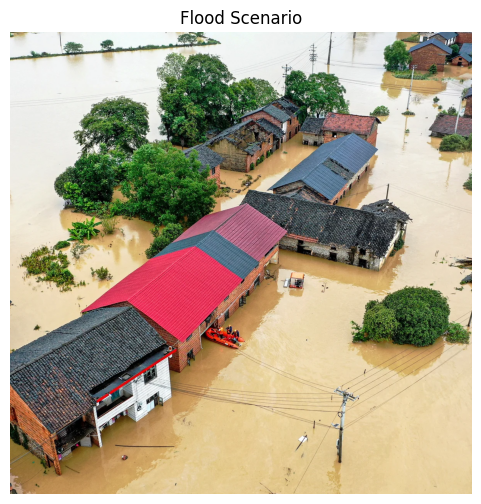

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image directly from the Colab Files panel
image = Image.open("/content/floodimage.webp").convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Flood Scenario")
plt.show()

In [ ]:
inputs = processor(image, return_tensors="pt").to(device)

output = blip_model.generate(
    **inputs,
    max_new_tokens=50
)

caption = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("Image Caption:")
print(caption)

Image Caption:
a flooded street with houses and a red roof


In [ ]:
# BLIP MODEL SIZE COMPARISON

import time
import pandas as pd

blip_comparison_images = {
    "Flood": "/content/floodimage.webp",
    "Fire": "/content/fireimage.jpeg",
    "Earthquake": "/content/earthquake.jpg"
}

blip_comparison_results = []

for model_name in [
    "Salesforce/blip-image-captioning-base",
    "Salesforce/blip-image-captioning-large"
]:
    print(f"Loading {model_name}...")

    start_load = time.time()
    comparison_processor = BlipProcessor.from_pretrained(model_name)
    comparison_blip_model = BlipForConditionalGeneration.from_pretrained(model_name)
    comparison_blip_model.to(device)
    load_time = time.time() - start_load

    for scenario, image_path in blip_comparison_images.items():
        comparison_image = Image.open(image_path).convert("RGB")

        start_caption = time.time()
        comparison_inputs = comparison_processor(
            comparison_image, return_tensors="pt"
        ).to(device)

        comparison_output = comparison_blip_model.generate(
            **comparison_inputs, max_new_tokens=50
        )

        comparison_caption = comparison_processor.decode(
            comparison_output[0], skip_special_tokens=True
        )
        caption_time = time.time() - start_caption

        blip_comparison_results.append({
            "Model": model_name.split("/")[-1],
            "Scenario": scenario,
            "Caption": comparison_caption,
            "Load Time (s)": round(load_time, 2),
            "Caption Time (s)": round(caption_time, 2)
        })

    # Free memory before loading the next model
    del comparison_processor, comparison_blip_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

blip_comparison_df = pd.DataFrame(blip_comparison_results)

print("\n===== BLIP MODEL COMPARISON =====")
display(blip_comparison_df)

Loading Salesforce/blip-image-captioning-base...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading Salesforce/blip-image-captioning-large...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.60k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.88GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]


===== BLIP MODEL COMPARISON =====


,Model,Scenario,Caption,Load Time (s),Caption Time (s)
0,blip-image-captioning-base,Flood,a flooded street with houses and a red roof,8.52,0.71
1,blip-image-captioning-base,Fire,a house is engulfed by fire,8.52,0.37
2,blip-image-captioning-base,Earthquake,a view of the destroyed city of kabul,8.52,0.62
3,blip-image-captioning-large,Flood,flooded houses in a village with a red roof an...,114.46,0.41
4,blip-image-captioning-large,Fire,a firefighter in front of a house engulfed by ...,114.46,0.32
5,blip-image-captioning-large,Earthquake,arafed view of a city with a lot of rubble and...,114.46,0.35


In [ ]:
for row in blip_comparison_results:
    print(f"--- {row['Model']} | {row['Scenario']} ---")
    print(row["Caption"])
    print()

--- blip-image-captioning-base | Flood ---
a flooded street with houses and a red roof

--- blip-image-captioning-base | Fire ---
a house is engulfed by fire

--- blip-image-captioning-base | Earthquake ---
a view of the destroyed city of kabul

--- blip-image-captioning-large | Flood ---
flooded houses in a village with a red roof and a red roof

--- blip-image-captioning-large | Fire ---
a firefighter in front of a house engulfed by flames

--- blip-image-captioning-large | Earthquake ---
arafed view of a city with a lot of rubble and buildings



In [ ]:
image_caption = caption

print("Saved Image Caption:")
print(image_caption)

Saved Image Caption:
a flooded street with houses and a red roof


In [ ]:
image_caption = caption

prompt = f"""
You are an emergency response assistant.

A disaster image was analysed by BLIP.

Image Caption:
{image_caption}

Based only on this image caption, provide:

Incident Summary:
Severity Level: Low, Medium, High, or Critical
Priority Recommendation:
Reasoning:
"""

inputs = llm_tokenizer(prompt, return_tensors="pt").to(llm_model.device)

outputs = llm_model.generate(
    **inputs,
    max_new_tokens=200,
    temperature=0.3,
    do_sample=True
)

image_assessment = llm_tokenizer.decode(outputs[0], skip_special_tokens=True)

print(image_assessment)

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are an emergency response assistant.

A disaster image was analysed by BLIP.

Image Caption:
a flooded street with houses and a red roof

Based only on this image caption, provide:

Incident Summary:
Severity Level: Low, Medium, High, or Critical
Priority Recommendation:
Reasoning:

Critical Incident:
The flooding caused significant damage to the homes and businesses in the area. The floodwaters were high and the roads were flooded, making it difficult for emergency responders to access the affected areas. The incident resulted in the loss of life, injuries, and property damage.

Medium Incident:
The flooding caused some damage to the roads, but the emergency responders were able to reach the affected areas. The incident resulted in the loss of some property and the inconvenience of the affected residents.

Low Incident:
The flooding caused some damage to the homes, but the emergency responders were able to reach the affected areas. The incident resulted in the loss of some proper

In [ ]:
prompt = f"""
You are an emergency disaster analyst.

The following caption was generated from a disaster image:

{image_caption}

Assume the image may contain flooding, damage, or emergency conditions.

Provide:

Incident Summary:
Severity Level (Low, Medium, High, Critical):
Priority Recommendation:
Reasoning:

Focus on disaster response and public safety.
"""

inputs = llm_tokenizer(prompt, return_tensors="pt").to(llm_model.device)

outputs = llm_model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.2,
    do_sample=True
)

answer = llm_tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

[transformers] Both `max_new_tokens` (=150) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



You are an emergency disaster analyst.

The following caption was generated from a disaster image:

a flooded street with houses and a red roof

Assume the image may contain flooding, damage, or emergency conditions.

Provide:

Incident Summary:
Severity Level (Low, Medium, High, Critical):
Priority Recommendation:
Reasoning:

Focus on disaster response and public safety.

Include a call-to-action for viewers to take action and provide feedback.

Include a call-to-action for viewers to share the video on social media.

Include a call-to-action for viewers to provide feedback on the video.

Include a call-to-action for viewers to provide feedback on the video.

Include a call-to-action for viewers to provide feedback on the video.

Include a call-to-action for viewers to provide feedback on the video.

Include a call-to-action for viewers to provide feedback on the video.

Include a call-to-action for viewers to provide feedback on the


In [ ]:
prompt = f"""
Task: Analyse a disaster image caption for emergency response.

Image caption:
{image_caption}

Return ONLY this format:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:

Rules:
- Do not write social media advice.
- Do not write calls to action.
- Focus only on emergency response.
- If flooding affects houses or streets, severity should be at least High.
"""

inputs = llm_tokenizer(prompt, return_tensors="pt").to(llm_model.device)

outputs = llm_model.generate(
    **inputs,
    max_new_tokens=120,
    temperature=0.1,
    do_sample=False
)

answer = llm_tokenizer.decode(outputs[0], skip_special_tokens=True)

print(answer)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task: Analyse a disaster image caption for emergency response.

Image caption:
a flooded street with houses and a red roof

Return ONLY this format:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:

Rules:
- Do not write social media advice.
- Do not write calls to action.
- Focus only on emergency response.
- If flooding affects houses or streets, severity should be at least High.
- If flooding affects a red roof, severity should be at least Medium.
- If flooding affects a red roof, priority should be at least High.
- If flooding affects a red roof, reason should be at least Medium.
- If flooding affects a red roof, reason should be at least High.
- If flooding affects a red roof, priority should be at least High.
- If flooding affects a red roof, reason should be at least High.
- If flooding affects a red roof


## Final Pipeline Implementation

Everything from this point onward is the actual, reusable AI Disaster Response
Coordinator system: the core functions (`build_combined_report`, `validate_assessment`,
`analyse_incident`), the evaluation framework, and the Gradio interface.

In [12]:
text_report = """
Local responders report that flood water is surrounding several houses.
A vehicle may be trapped near the main road.
Water levels are still rising and residents may need urgent evacuation.
"""

print("Manual Text Report:")
print(text_report)

Manual Text Report:

Local responders report that flood water is surrounding several houses.
A vehicle may be trapped near the main road.
Water levels are still rising and residents may need urgent evacuation.



In [13]:
def build_combined_report(audio_report=None, image_caption=None, text_report=None):
    """
    Combines whichever incident information sources are available.
    Audio, image and text inputs are optional.
    """

    available_information = []

    if audio_report is not None and str(audio_report).strip():
        available_information.append(
            f"AUDIO REPORT:\n{str(audio_report).strip()}"
        )

    if image_caption is not None and str(image_caption).strip():
        available_information.append(
            f"IMAGE CAPTION:\n{str(image_caption).strip()}"
        )

    if text_report is not None and str(text_report).strip():
        available_information.append(
            f"TEXT REPORT:\n{str(text_report).strip()}"
        )

    if not available_information:
        raise ValueError(
            "No incident information was provided. "
            "At least one input is required."
        )

    return "\n\n".join(available_information)


In [14]:
import re

def validate_assessment(assessment):
    """
    Validates the language model's assessment for required structure,
    allowed severity values, and non-empty output fields.
    """

    issues = []

    # Expected fields
    required_fields = [
        "Incident Summary",
        "Severity Level",
        "Priority Recommendation",
        "Reasoning"
    ]

    # Check that every required heading exists
    for field in required_fields:
        pattern = rf"{re.escape(field)}\s*:"
        if not re.search(pattern, assessment, re.IGNORECASE):
            issues.append(f"Missing required field: {field}:")


        # Extract severity.

    severity_field = re.search(
        r"Severity Level\s*:\s*(.+?)(?=\n[\s*#_]*Priority Recommendation\s*:|\Z)",
        assessment,
        re.IGNORECASE | re.DOTALL
    )

    severity_match = None
    if severity_field:
        severity_match = re.search(
            r"\b(Low|Medium|High|Critical)\b",
            severity_field.group(1),
            re.IGNORECASE
        )

    if severity_match:
        severity = severity_match.group(1).capitalize()
    else:
        severity = None
        issues.append(
            "Severity Level must be exactly one of: "
            "Low, Medium, High, Critical."
        )

    # Check that each field actually contains content
    field_patterns = {
        "Incident Summary": r"Incident Summary\s*:\s*(.+?)(?=\n[\s*#_]*Severity Level\s*:|\Z)",
        "Priority Recommendation": r"Priority Recommendation\s*:\s*(.+?)(?=\n[\s*#_]*Reasoning\s*:|\Z)",
        "Reasoning": r"Reasoning\s*:\s*(.+)"
    }

    field_matches = {}

    for field, pattern in field_patterns.items():
        match = re.search(
            pattern,
            assessment,
            re.IGNORECASE | re.DOTALL
        )

        if not match or not match.group(1).strip():
            issues.append(f"{field} is empty or could not be extracted.")
        else:
            field_matches[field] = match.group(1).strip()


    priority_text = field_matches.get("Priority Recommendation", "")

    LOW_SEVERITY_MISMATCH_KEYWORDS = [
        "immediate", "urgent", "urgently", "highest priority",
        "emergency intervention", "rescue team", "dispatch emergency"
    ]

    CRITICAL_SEVERITY_MISMATCH_KEYWORDS = [
        "routine", "monitor only", "no action", "no urgent", "low priority"
    ]

    priority_consistent = True

    if severity == "Low" and any(
        keyword in priority_text.lower()
        for keyword in LOW_SEVERITY_MISMATCH_KEYWORDS
    ):
        priority_consistent = False
        issues.append(
            "Priority Recommendation appears inconsistent with a Low "
            "severity classification (uses urgent/emergency wording)."
        )

    if severity == "Critical" and any(
        keyword in priority_text.lower()
        for keyword in CRITICAL_SEVERITY_MISMATCH_KEYWORDS
    ):
        priority_consistent = False
        issues.append(
            "Priority Recommendation appears inconsistent with a Critical "
            "severity classification (uses routine/low-urgency wording)."
        )



    bad_patterns = [
        r"Severity Level\s*\(\s*1\s*[-–]\s*4\s*\)",
        r"Additional Information\s*:",
        r"Low\s*[-–]\s*No immediate",
        r"Medium\s*[-–]\s*Some risk"
    ]

    for pattern in bad_patterns:
        if re.search(pattern, assessment, re.IGNORECASE):
            issues.append(
                "The model produced an invalid explanatory/template response "
                "instead of the required structured assessment."
            )
            break


    return {
        "valid": len(issues) == 0,
        "severity": severity,
        "issues": issues,
        "priority_consistent": priority_consistent
    }

In [15]:
# UNIT TESTS FOR validate_assessment()
# These tests check that the validator correctly accepts well-formed,
# consistent assessments and correctly rejects malformed or
# internally-inconsistent ones.

def run_validation_tests():

    # TEST 1: A well-formed, internally consistent assessment should pass.
    valid_case = """
Incident Summary:
Severe flooding near a main road trapping two individuals in their vehicle.

Severity Level:
High

Priority Recommendation:
Dispatch emergency response resources urgently.

Reasoning:
Multiple people are trapped in floodwater with rapidly worsening conditions.
"""
    result = validate_assessment(valid_case)
    assert result["valid"] is True, "TEST 1 FAILED: expected a valid, well-formed assessment to pass."
    assert result["severity"] == "High", "TEST 1 FAILED: expected severity 'High' to be extracted correctly."
    print("TEST 1 PASSED: valid, consistent assessment correctly accepted.")

    # TEST 2: An invalid severity word ("Severe") must be rejected.
    invalid_severity_case = """
**Incident Summary:** A warehouse fire has erupted, creating thick smoke.

**Severity Level:** Severe

**Priority Recommendation:** Immediate deployment of fire services.

**Reasoning:** High risk to human life due to inhalation hazards.
"""
    result = validate_assessment(invalid_severity_case)
    assert result["valid"] is False, "TEST 2 FAILED: expected an invalid severity word to be rejected."
    assert result["severity"] is None, "TEST 2 FAILED: expected no severity to be extracted for 'Severe'."
    print("TEST 2 PASSED: invalid severity word ('Severe') correctly rejected.")

    # TEST 3: A Low severity paired with urgent/emergency priority wording
    # must be flagged as inconsistent.
    low_mismatch_case = """
Incident Summary:
Minor incident, no danger reported.

Severity Level:
Low

Priority Recommendation:
Dispatch emergency rescue teams immediately, highest priority.

Reasoning:
Testing the consistency check.
"""
    result = validate_assessment(low_mismatch_case)
    assert result["valid"] is False, "TEST 3 FAILED: expected Low severity + urgent priority to be rejected."
    assert result["priority_consistent"] is False, "TEST 3 FAILED: expected priority_consistent to be False."
    print("TEST 3 PASSED: Low severity + urgent priority wording correctly flagged as inconsistent.")

    # TEST 4: A Critical severity paired with routine/low-urgency priority
    # wording must also be flagged as inconsistent.
    critical_mismatch_case = """
Incident Summary:
Building has collapsed with people trapped beneath debris.

Severity Level:
Critical

Priority Recommendation:
Routine monitoring, no urgent action needed.

Reasoning:
Testing the consistency check.
"""
    result = validate_assessment(critical_mismatch_case)
    assert result["valid"] is False, "TEST 4 FAILED: expected Critical severity + routine priority to be rejected."
    assert result["priority_consistent"] is False, "TEST 4 FAILED: expected priority_consistent to be False."
    print("TEST 4 PASSED: Critical severity + routine priority wording correctly flagged as inconsistent.")

    # TEST 5: A response missing a required field entirely must be rejected.
    missing_field_case = """
Incident Summary:
Minor incident, no danger reported.

Severity Level:
Low

Priority Recommendation:
Monitor the situation.
"""
    result = validate_assessment(missing_field_case)
    assert result["valid"] is False, "TEST 5 FAILED: expected a response missing 'Reasoning' to be rejected."
    print("TEST 5 PASSED: response missing a required field correctly rejected.")

    print("\nALL VALIDATION TESTS PASSED.")


run_validation_tests()

TEST 1 PASSED: valid, consistent assessment correctly accepted.
TEST 2 PASSED: invalid severity word ('Severe') correctly rejected.
TEST 3 PASSED: Low severity + urgent priority wording correctly flagged as inconsistent.
TEST 4 PASSED: Critical severity + routine priority wording correctly flagged as inconsistent.
TEST 5 PASSED: response missing a required field correctly rejected.

ALL VALIDATION TESTS PASSED.


In [ ]:
test_missing_image = build_combined_report(
    audio_report=incident_report,
    image_caption=None,
    text_report=text_report
)

print(test_missing_image)

AUDIO REPORT:
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

TEXT REPORT:
Local responders report that flood water is surrounding several houses.
A vehicle may be trapped near the main road.
Water levels are still rising and residents may need urgent evacuation.


In [15]:
# CLEAR SEVERITY AND PRIORITY RULES
#
# Explicit, evidence-based rules are given to the model instead of asking
# it to judge severity freely. This keeps classifications consistent
# across incidents and stops the model escalating severity just because
# a disaster type (e.g. earthquake) sounds inherently dangerous.
TRIAGE_RULES = """
SEVERITY AND PRIORITY RULES:

LOW:
- Minor incident with no evidence of immediate danger to people.
- No trapped, injured, missing, or threatened people reported.
- Conditions appear stable.
- Priority: Monitor the situation and use routine response resources.

MEDIUM:
- Incident may affect people, property, roads, or infrastructure.
- Some risk is present, but there is no clear evidence of immediate life-threatening danger.
- Conditions may require intervention to prevent escalation.
- Priority: Respond promptly and continue monitoring for deterioration.

HIGH:
- People are trapped, injured, displaced, or in immediate danger.
- Significant fire, flooding, structural damage, or access problems are reported.
- Conditions are worsening or emergency assistance is urgently required.
- Priority: Dispatch emergency response resources urgently.

CRITICAL:
- There is clear evidence of immediate threat to life involving one or more people.
- Multiple people may be trapped or seriously endangered.
- There is severe or rapidly escalating flooding, fire, collapse, or another major hazard.
- Delay in response could reasonably result in serious injury or loss of life.
- Priority: Immediate emergency intervention and highest response priority.

IMPORTANT:
- Base the decision only on the supplied incident evidence.
- Do not assume casualties, injuries, damage, or hazards that are not reported.
- If evidence is insufficient to justify a higher category, choose the lower supported severity.
"""

In [16]:
import os
def analyse_incident(audio_path=None, image_path=None, text_report=None):
    """
    Runs the complete AI Disaster Response Coordinator pipeline.

    The function can accept audio, image, text, or any combination
    of the three inputs.
    """

    transcript = None
    caption = None

    # Check that supplied file paths actually exist before processing.

    if audio_path is not None and not os.path.exists(audio_path):
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    if image_path is not None and not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # STEP 1: Process audio with Whisper
    if audio_path is not None:
        audio_result = model.transcribe(audio_path)
        transcript = audio_result["text"].strip()

    # STEP 2: Process image with BLIP
    if image_path is not None:
        incident_image = Image.open(image_path).convert("RGB")

        image_inputs = processor(
            incident_image,
            return_tensors="pt"
        ).to(device)

        image_output = blip_model.generate(
            **image_inputs,
            max_new_tokens=50
        )

        caption = processor.decode(
            image_output[0],
            skip_special_tokens=True
        ).strip()

    # STEP 3: Combine whichever information sources are available
    combined_information = build_combined_report(
        audio_report=transcript,
        image_caption=caption,
        text_report=text_report
    )

    # STEP 4: Send combined information to the LLM

    EXAMPLE_OUTPUT = """
    Incident Summary:
    A small kitchen fire was reported and extinguished before spreading. No injuries reported.

    Severity Level:
    Low

    Priority Recommendation:
    Monitor the situation; no urgent response required.

    Reasoning:
    The fire was contained with no reported injuries or ongoing hazard.
    """

    prompt = f"""
    You are a disaster triage decision-support system.

    Here is an example of the exact response format required:
    {EXAMPLE_OUTPUT}

    Now assess the real incident below using the same exact format.

    INCIDENT EVIDENCE:
    {combined_information}

    {TRIAGE_RULES}

    Use only the incident evidence provided above.
    Do not invent facts.
    If information is unavailable, say Unknown.

    Severity Level must be exactly one of:
    Low, Medium, High, Critical.

    The Priority Recommendation must be consistent with the selected severity level.

    Complete exactly these four fields and nothing else:

    Incident Summary:
    Severity Level:
    Priority Recommendation:
    Reasoning:
    """

    messages = [
    {
        "role": "system",
        "content": (
            "You are an AI disaster triage decision-support assistant. "
            "Use only the incident evidence provided. "
            "Do not invent facts."
        )
    },
    {
        "role": "user",
        "content": prompt
    }
]

    formatted_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    llm_inputs = llm_tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(llm_model.device)


    llm_outputs = llm_model.generate(
        **llm_inputs,
        **GENERATION_CONFIG,
        pad_token_id=llm_tokenizer.eos_token_id,
        eos_token_id=llm_tokenizer.eos_token_id
    )

    input_length = llm_inputs["input_ids"].shape[1]

    generated_tokens = llm_outputs[0][input_length:]

    final_assessment = llm_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()
    first_attempt_raw = final_assessment

    validation = validate_assessment(final_assessment)

        # STEP 5: Retry once if the output is invalid
    retry_used = False
    retry_assessment = None
    retry_validation = None

    if not validation["valid"]:
        retry_used = True

        correction_prompt = f"""
  Use only the incident evidence below.

  {combined_information}

  Answer the following four questions briefly.

  1. Summarise the incident in one or two sentences.
  2. Choose exactly one severity: Low, Medium, High, or Critical.
  3. Give one short priority recommendation.
  4. Give one short reason for that decision.

  Do not repeat the input reports.
  Do not explain the severity scale.
  Do not invent facts.

  Return exactly four lines in this order:

  SUMMARY=<answer>
  SEVERITY=<Low, Medium, High, or Critical>
  PRIORITY=<answer>
  REASON=<answer>
  """

        retry_messages = [
            {
                "role": "system",
                "content": (
                    "You are an AI disaster triage decision-support assistant. "
                    "Follow the requested output format exactly. "
                    "Use only the supplied evidence. "
                    "Do not invent facts."
                )
            },
            {
                "role": "user",
                "content": correction_prompt
            }
        ]

        retry_formatted_prompt = llm_tokenizer.apply_chat_template(
            retry_messages,
            tokenize=False,
            add_generation_prompt=True
        )

        retry_inputs = llm_tokenizer(
            retry_formatted_prompt,
            return_tensors="pt"
        ).to(llm_model.device)


        retry_outputs = llm_model.generate(
            **retry_inputs,
            **RETRY_GENERATION_CONFIG,
            pad_token_id=llm_tokenizer.eos_token_id,
            eos_token_id=llm_tokenizer.eos_token_id
        )

        retry_input_length = retry_inputs["input_ids"].shape[1]
        retry_generated_tokens = retry_outputs[0][retry_input_length:]

        retry_assessment = llm_tokenizer.decode(
            retry_generated_tokens,
            skip_special_tokens=True
        ).strip()

        summary_match = re.search(
            r"SUMMARY\s*=\s*(.+)",
            retry_assessment,
            re.IGNORECASE
        )

        severity_match = re.search(
            r"SEVERITY\s*=\s*(Low|Medium|High|Critical)\b",
            retry_assessment,
            re.IGNORECASE
        )

        priority_match = re.search(
            r"PRIORITY\s*=\s*(.+)",
            retry_assessment,
            re.IGNORECASE
        )

        reason_match = re.search(
            r"REASON\s*=\s*(.+)",
            retry_assessment,
            re.IGNORECASE
        )

        if (
            summary_match
            and severity_match
            and priority_match
            and reason_match
        ):
            retry_assessment = f"""Incident Summary:
  {summary_match.group(1).strip()}

  Severity Level:
  {severity_match.group(1).capitalize()}

  Priority Recommendation:
  {priority_match.group(1).strip()}

  Reasoning:
  {reason_match.group(1).strip()}
  """

        retry_validation = validate_assessment(retry_assessment)

        # Use the retry only if it passes validation
        if retry_validation["valid"]:
            final_assessment = retry_assessment
            validation = retry_validation


    # STEP 6: Safe failure if both attempts are invalid
    if validation["valid"]:
        system_status = "VALIDATED"
        human_review_required = False
    else:
        system_status = "FAILED_VALIDATION"
        human_review_required = True

        final_assessment = (
            "AI assessment unavailable because the generated response "
            "failed output validation. Human review is required."
        )

    # Return all important stages of the pipeline
    return {
        "audio_transcript": transcript,
        "image_caption": caption,
        "text_report": text_report,
        "combined_information": combined_information,
        "first_attempt_raw": first_attempt_raw,
        "final_assessment": final_assessment,
        "validation": validation,
        "retry_used": retry_used,
        "retry_assessment": retry_assessment,
        "retry_validation": retry_validation,
        "system_status": system_status,
        "human_review_required": human_review_required
    }

In [38]:
!pip install -q gradio

In [39]:
import gradio as gr
import tempfile

SEVERITY_COLORS = {
    "Low": "#4CAF50",
    "Medium": "#FFC107",
    "High": "#FF9800",
    "Critical": "#F44336"
}

def build_severity_badge(severity_label):
    color = SEVERITY_COLORS.get(severity_label, "#9E9E9E")
    display_text = severity_label if severity_label else "Not Available"
    return (
        f'<div style="background-color:{color}; color:white; '
        f'padding:14px; border-radius:8px; font-size:22px; '
        f'font-weight:bold; text-align:center;">'
        f'Severity: {display_text}</div>'
    )

def run_ui_analysis(audio_file, image_file, text_report):

    audio_path = audio_file if audio_file else None
    image_path = image_file if image_file else None

    if text_report is not None:
        text_report = text_report.strip()

    if not text_report:
        text_report = None

    # Require at least one input
    if audio_path is None and image_path is None and text_report is None:
        return (
            "No audio supplied.",
            "No image supplied.",
            "Please provide at least one source of incident information.",
            "NO INPUT",
            "Yes",
            build_severity_badge(None),
            None
        )

    try:
        result = analyse_incident(
            audio_path=audio_path,
            image_path=image_path,
            text_report=text_report
        )

        transcript = (
            result["audio_transcript"]
            if result["audio_transcript"]
            else "No audio supplied."
        )

        caption = (
            result["image_caption"]
            if result["image_caption"]
            else "No image supplied."
        )

        assessment = result["final_assessment"]
        status = result["system_status"]
        severity_label = result["validation"]["severity"]

        human_review = (
            "Yes"
            if result["human_review_required"]
            else "No"
        )

        # Write a downloadable plain-text summary of the assessment
        summary_text = (
            "AI DISASTER RESPONSE COORDINATOR - INCIDENT SUMMARY\n"
            "=====================================================\n\n"
            f"Audio Transcript:\n{transcript}\n\n"
            f"Image Caption:\n{caption}\n\n"
            f"Emergency Assessment:\n{assessment}\n\n"
            f"System Status: {status}\n"
            f"Human Review Required: {human_review}\n"
        )

        summary_file = tempfile.NamedTemporaryFile(
            mode="w",
            suffix=".txt",
            delete=False
        )
        summary_file.write(summary_text)
        summary_file.close()

        return (
            transcript,
            caption,
            assessment,
            status,
            human_review,
            build_severity_badge(severity_label),
            summary_file.name
        )

    except Exception as error:
        return (
            "Audio processing unavailable.",
            "Image processing unavailable.",
            f"System error: {str(error)}",
            "ERROR",
            "Yes",
            build_severity_badge(None),
            None
        )

In [40]:
with gr.Blocks(
    title="AI Disaster Response Coordinator",
    css="""
    #analyse-btn {
        background-color: #FF69B4 !important;
        border-color: #FF69B4 !important;
        color: white !important;
    }
    #analyse-btn:hover {
        background-color: #FF1493 !important;
        border-color: #FF1493 !important;
    }
    """
) as demo:

    gr.Markdown(
        """
        # 🚨 AI Disaster Response Coordinator
        ### Multimodal AI System for Emergency Prioritisation

        This prototype combines **Whisper**, **BLIP**, and **Qwen2.5-1.5B**
        to analyse available emergency information and generate a
        structured incident assessment.

        **Decision-support prototype only — final decisions remain under human supervision.**
        """
    )

    gr.Markdown("## Incident Information")

    with gr.Row():
        audio_input = gr.Audio(
            label="🎤 Emergency Audio",
            type="filepath"
        )

        image_input = gr.Image(
            label="🖼️ Disaster Image",
            type="filepath"
        )

    text_input = gr.Textbox(
        label="📝 Written Incident Report",
        placeholder="Enter any additional incident information here...",
        lines=5
    )

    analyse_button = gr.Button(
        "Analyse Incident",
        variant="primary",
        elem_id="analyse-btn"
    )

    gr.Markdown("---")

    gr.Markdown("## AI Processing Results")

    transcript_output = gr.Textbox(
        label="Whisper Audio Transcript",
        lines=4,
        interactive=False
    )

    caption_output = gr.Textbox(
        label="BLIP Image Caption",
        lines=3,
        interactive=False
    )


    severity_badge_output = gr.HTML(
        label="Severity Indicator"
    )

    assessment_output = gr.Textbox(
        label="Emergency Assessment",
        lines=10,
        interactive=False
    )

    download_output = gr.File(
        label="📥 Download Incident Summary"
    )

    with gr.Row():
        status_output = gr.Textbox(
            label="System Status",
            interactive=False
        )

        human_review_output = gr.Textbox(
            label="Human Review Required",
            interactive=False
        )

    analyse_button.click(
        fn=run_ui_analysis,
        inputs=[
            audio_input,
            image_input,
            text_input
        ],
        outputs=[
            transcript_output,
            caption_output,
            assessment_output,
            status_output,
            human_review_output,
            severity_badge_output,
            download_output
        ]
    )

/tmp/ipykernel_2779/1914114397.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(


In [41]:
demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://90fbd042c26e704295.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.13/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://90fbd042c26e704295.gradio.live


In [23]:
# TEST-CASE DATASET FOR SYSTEM EVALUATION

test_cases = [

    # -------------------------
    # LOW SEVERITY
    # -------------------------

    {
        "id": "TC01",
        "disaster_type": "Flood",
        "text_report": (
            "Light flooding is reported in an empty car park. "
            "No people are trapped or injured. Water levels are stable."
        ),
        "expected_severity": "Low",
        "expected_priority": "Routine monitoring"
    },

    {
        "id": "TC02",
        "disaster_type": "Fire",
        "text_report": (
            "A small outdoor bin fire has been extinguished. "
            "No injuries or nearby hazards are reported and the area is safe."
        ),
        "expected_severity": "Low",
        "expected_priority": "Routine monitoring"
    },

    {
        "id": "TC03",
        "disaster_type": "Earthquake",
        "text_report": (
            "A minor tremor was felt in the area. "
            "No injuries, structural damage, or immediate hazards have been reported."
        ),
        "expected_severity": "Low",
        "expected_priority": "Routine monitoring"
    },

    # -------------------------
    # MEDIUM SEVERITY
    # -------------------------

    {
        "id": "TC04",
        "disaster_type": "Flood",
        "text_report": (
            "Flood water is covering part of a residential road. "
            "No people are trapped, but vehicle access is becoming difficult."
        ),
        "expected_severity": "Medium",
        "expected_priority": "Prompt response"
    },

    {
        "id": "TC05",
        "disaster_type": "Fire",
        "text_report": (
            "Smoke is coming from a storage building. "
            "Everyone has evacuated and no injuries are reported, "
            "but firefighters are required to control the situation."
        ),
        "expected_severity": "Medium",
        "expected_priority": "Prompt response"
    },

    {
        "id": "TC06",
        "disaster_type": "Earthquake",
        "text_report": (
            "An earthquake has caused cracks in several buildings. "
            "No injuries are currently reported, but the buildings require inspection."
        ),
        "expected_severity": "Medium",
        "expected_priority": "Prompt response"
    },

    # -------------------------
    # HIGH SEVERITY
    # -------------------------

    {
        "id": "TC07",
        "disaster_type": "Flood",
        "text_report": (
            "Flood water is rising around several homes. "
            "Residents are being evacuated and road access is becoming blocked."
        ),
        "expected_severity": "High",
        "expected_priority": "Urgent emergency response"
    },

    {
        "id": "TC08",
        "disaster_type": "Fire",
        "text_report": (
            "A large warehouse fire is producing thick smoke. "
            "Workers are evacuating and emergency services are urgently required."
        ),
        "expected_severity": "High",
        "expected_priority": "Urgent emergency response"
    },

    {
        "id": "TC09",
        "disaster_type": "Earthquake",
        "text_report": (
            "An earthquake has damaged several buildings and blocked roads. "
            "Some residents require evacuation and emergency assistance."
        ),
        "expected_severity": "High",
        "expected_priority": "Urgent emergency response"
    },

    # -------------------------
    # CRITICAL SEVERITY
    # -------------------------

    {
        "id": "TC10",
        "disaster_type": "Flood",
        "text_report": (
            "Two people are trapped inside a vehicle during severe flooding. "
            "Water levels are rising rapidly and immediate rescue is required."
        ),
        "expected_severity": "Critical",
        "expected_priority": "Immediate highest-priority response"
    },

    {
        "id": "TC11",
        "disaster_type": "Fire",
        "text_report": (
            "Several people are trapped inside a burning building. "
            "The fire is spreading rapidly and there is an immediate threat to life."
        ),
        "expected_severity": "Critical",
        "expected_priority": "Immediate highest-priority response"
    },

    {
        "id": "TC12",
        "disaster_type": "Earthquake",
        "text_report": (
            "A building has collapsed following a major earthquake. "
            "Several people are trapped beneath the debris and immediate rescue is required."
        ),
        "expected_severity": "Critical",
        "expected_priority": "Immediate highest-priority response"
    }
]


print("Test-case dataset created successfully.")
print("Number of test cases:", len(test_cases))

Test-case dataset created successfully.
Number of test cases: 12


In [24]:
# SELECT 4 REPRESENTATIVE CASES FOR PROMPT COMPARISON

prompt_comparison_cases = [
    test_cases[0],   # TC01 - Low
    test_cases[3],   # TC04 - Medium
    test_cases[6],   # TC07 - High
    test_cases[9]    # TC10 - Critical
]

print("Representative prompt-comparison cases selected.")
print("Number of cases:", len(prompt_comparison_cases))

for case in prompt_comparison_cases:
    print(
        case["id"],
        "-",
        case["disaster_type"],
        "- Expected severity:",
        case["expected_severity"]
    )

Representative prompt-comparison cases selected.
Number of cases: 4
TC01 - Flood - Expected severity: Low
TC04 - Flood - Expected severity: Medium
TC07 - Flood - Expected severity: High
TC10 - Flood - Expected severity: Critical


In [25]:
# CREATE PROMPT A/B/C FOR ANY TEST CASE

def create_prompt_variants(case):

    incident_text = case["text_report"]

    prompt_A = f"""
You are an emergency response assistant.

Analyse the following disaster incident:

{incident_text}

Provide:
1. Incident Summary
2. Severity Level: Low, Medium, High, or Critical
3. Priority Recommendation
4. Reasoning
"""

    prompt_B = f"""
You are helping emergency services prioritise disaster reports.

Use the incident information below:

{incident_text}

Return your answer in this exact format:

Incident Summary:
Severity Level:
Priority Recommendation:
Key Evidence:
"""

    prompt_C = f"""
Act as a disaster triage AI system.

Task:
Assess the emergency severity based only on the information provided.

Incident information:

{incident_text}

Rules:
- If people are trapped or lives are at risk, severity should be High or Critical.
- If conditions are worsening quickly, increase priority.
- Give a clear rescue recommendation.

Output:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:
"""

    return {
        "A": prompt_A,
        "B": prompt_B,
        "C": prompt_C
    }


print("Dynamic Prompt A/B/C function created successfully.")

Dynamic Prompt A/B/C function created successfully.


In [26]:
# CONTROLLED DETERMINISTIC PROMPT RUNNER

def run_prompt_comparison(prompt):

    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI disaster triage decision-support assistant. "
                "Use only the incident evidence provided. "
                "Do not invent facts."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    # apply_chat_template() is required here because the LLM is an
    # instruction-tuned chat model. Without it, the model treats the
    # prompt as plain text to continue rather than a question to answer.
    formatted_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(llm_model.device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        pad_token_id=llm_tokenizer.eos_token_id,
        eos_token_id=llm_tokenizer.eos_token_id
    )

    input_length = inputs["input_ids"].shape[1]

    generated_tokens = outputs[0][input_length:]

    answer = llm_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return answer


print("Controlled deterministic prompt runner created successfully.")

Controlled deterministic prompt runner created successfully.


In [27]:
# MULTI-CASE PROMPT SCORING FUNCTION

def evaluate_prompt_output_for_case(output_text, case):
    output_lower = output_text.lower()

    expected_severity = case["expected_severity"]


    severity_field = re.search(
        r"Severity Level\s*:\s*(.+?)(?=\n\s*Priority Recommendation\s*:|\Z)",
        output_text,
        re.IGNORECASE | re.DOTALL
    )


    severity_match = None
    if severity_field:
        severity_match = re.search(
            r"\b(Low|Medium|High|Critical)\b",
            severity_field.group(1),
            re.IGNORECASE
        )

    if severity_match:
        predicted_severity = severity_match.group(1).capitalize()
    else:
        # Allow wording such as "Low Emergency Severity"
        alternative_match = re.search(
            r"\b(low|medium|high|critical)\s+(?:emergency\s+)?severity\b",
            output_text,
            re.IGNORECASE
        )

        predicted_severity = (
            alternative_match.group(1).capitalize()
            if alternative_match
            else None
        )

    correct_severity = predicted_severity == expected_severity

    # 2. Check priority
    expected_priority = case["expected_priority"].lower()

    priority_terms = {
        "routine monitoring": [
            "monitor",
            "routine",
            "minimal",
            "no immediate"
        ],
        "prompt response": [
            "prompt",
            "respond",
            "intervention",
            "monitor"
        ],
        "urgent emergency response": [
            "urgent",
            "emergency",
            "evacuation",
            "dispatch"
        ],
        "immediate highest-priority response": [
            "immediate",
            "highest",
            "urgent",
            "rescue"
        ]
    }

    correct_priority = any(
        term in output_lower
        for term in priority_terms.get(expected_priority, [])
    )

    # 3. Required output format
    required_headings = [
        "incident summary:",
        "severity level:",
        "priority recommendation:",
        "reasoning:"
    ]

    valid_format = all(
        heading in output_lower
        for heading in required_headings
    )

    # 4. Unsupported facts
    incident_words = case["text_report"].lower()

    unsupported_patterns = [
        "fatality",
        "fatalities",
        "hospital",
        "chemical",
        "explosion",
        "five cars",
        "stay indoors"
    ]

    unsupported_facts = any(
        pattern in output_lower
        and pattern not in incident_words
        for pattern in unsupported_patterns
    )

    # 5. Relevant reasoning
    reasoning_keywords = [
        "flood",
        "fire",
        "earthquake",
        "water",
        "trapped",
        "injured",
        "evacuat",
        "damage",
        "risk",
        "stable",
        "rescue"
    ]

    relevant_reasoning = any(
        word in output_lower
        for word in reasoning_keywords
    )

    return {
        "Test Case": case["id"],
        "Expected Severity": expected_severity,
        "Predicted Severity": predicted_severity,
        "Correct Severity": correct_severity,
        "Correct Priority": correct_priority,
        "Valid Format": valid_format,
        "Unsupported Facts": unsupported_facts,
        "Relevant Reasoning": relevant_reasoning
    }


print("Multi-case prompt scoring function created successfully.")

Multi-case prompt scoring function created successfully.


In [28]:
# RUN AND SCORE PROMPT A/B/C FOR ALL 4 REPRESENTATIVE CASES

all_prompt_scores = []

for case in prompt_comparison_cases:

    prompts = create_prompt_variants(case)

    print(f"\n======================================")
    print("Testing:", case["id"])
    print("======================================")

    for prompt_name, prompt_text in prompts.items():

        answer = run_prompt_comparison(prompt_text)

        print(f"\n----- {case['id']} - PROMPT {prompt_name} -----")
        print(answer)

        score = evaluate_prompt_output_for_case(answer, case)
        score["Prompt"] = prompt_name

        print(f"\n----- {case['id']} PROMPT {prompt_name} SCORE -----")
        for key, value in score.items():
            print(f"{key}: {value}")

        all_prompt_scores.append(score)

print("\nPrompt A/B/C testing completed for all representative cases.")


Testing: TC01

----- TC01 - PROMPT A -----
**Incident Summary**
A light flood has occurred in a vacant car park with no individuals affected and water levels remaining constant.

**Severity Level:** Low

**Priority Recommendation:**

- Monitor water level changes closely.
- Ensure proper drainage systems are functioning to prevent overflow.
- Maintain communication between authorities for any potential future incidents.

**Reasoning:**
The severity of this incident is classified as low because there were no casualties or injuries, which indicates minimal risk to public safety. The fact that the water levels remained stable suggests that it was likely caused by external factors such as heavy rainwater runoff rather than internal issues within the facility itself. Given these circumstances, immediate action can be taken without escalating the situation further. Regular monitoring will help ensure that if conditions

----- TC01 PROMPT A SCORE -----
Test Case: TC01
Expected Severity: Low


In [29]:
# FINAL OBJECTIVE PROMPT COMPARISON
import pandas as pd

prompt_results_df = pd.DataFrame(all_prompt_scores)

print("===== ALL PROMPT TEST RESULTS =====")
display(prompt_results_df)

prompt_summary = (
    prompt_results_df
    .groupby("Prompt")
    .agg(
        Severity_Accuracy=("Correct Severity", "mean"),
        Priority_Accuracy=("Correct Priority", "mean"),
        Valid_Format_Rate=("Valid Format", "mean"),
        Unsupported_Fact_Rate=("Unsupported Facts", "mean"),
        Relevant_Reasoning_Rate=("Relevant Reasoning", "mean")
    )
    .reset_index()
)

prompt_summary["Severity_Accuracy"] *= 100
prompt_summary["Priority_Accuracy"] *= 100
prompt_summary["Valid_Format_Rate"] *= 100
prompt_summary["Unsupported_Fact_Rate"] *= 100
prompt_summary["Relevant_Reasoning_Rate"] *= 100

prompt_summary = prompt_summary.round(2)

print("\n===== PROMPT COMPARISON SUMMARY =====")
display(prompt_summary)

===== ALL PROMPT TEST RESULTS =====


,Test Case,Expected Severity,Predicted Severity,Correct Severity,Correct Priority,Valid Format,Unsupported Facts,Relevant Reasoning,Prompt
0,TC01,Low,Low,True,True,False,False,True,A
1,TC01,Low,Low,True,True,False,False,True,B
2,TC01,Low,None,False,True,False,False,True,C
3,TC04,Medium,Medium,True,False,False,False,True,A
4,TC04,Medium,None,False,False,False,True,True,B
5,TC04,Medium,None,False,True,False,False,True,C
6,TC07,High,High,True,True,False,False,True,A
7,TC07,High,High,True,True,False,False,True,B
8,TC07,High,None,False,True,False,False,True,C
9,TC10,Critical,High,False,True,False,True,True,A



===== PROMPT COMPARISON SUMMARY =====


,Prompt,Severity_Accuracy,Priority_Accuracy,Valid_Format_Rate,Unsupported_Fact_Rate,Relevant_Reasoning_Rate
0,A,75.0,75.0,0.0,25.0,100.0
1,B,75.0,75.0,0.0,25.0,100.0
2,C,0.0,100.0,0.0,0.0,100.0


In [30]:
import pandas as pd

test_df = pd.DataFrame(test_cases)

print(test_df[[
    "id",
    "disaster_type",
    "expected_severity",
    "expected_priority",
    "text_report"
]])

      id disaster_type expected_severity                    expected_priority  \
0   TC01         Flood               Low                   Routine monitoring   
1   TC02          Fire               Low                   Routine monitoring   
2   TC03    Earthquake               Low                   Routine monitoring   
3   TC04         Flood            Medium                      Prompt response   
4   TC05          Fire            Medium                      Prompt response   
5   TC06    Earthquake            Medium                      Prompt response   
6   TC07         Flood              High            Urgent emergency response   
7   TC08          Fire              High            Urgent emergency response   
8   TC09    Earthquake              High            Urgent emergency response   
9   TC10         Flood          Critical  Immediate highest-priority response   
10  TC11          Fire          Critical  Immediate highest-priority response   
11  TC12    Earthquake      

In [32]:
# VALIDATE TEST-CASE DATASET

required_fields = [
    "id",
    "disaster_type",
    "text_report",
    "expected_severity",
    "expected_priority"
]

# Check number of test cases
assert len(test_cases) == 12, "Dataset should contain 12 test cases."

# Check that every test case contains all required fields
for case in test_cases:
    for field in required_fields:
        assert field in case, f"{case.get('id', 'Unknown case')} is missing {field}"
        assert case[field], f"{case.get('id', 'Unknown case')} has an empty {field}"

# Check severity balance
severity_counts = test_df["expected_severity"].value_counts()

for severity in ["Low", "Medium", "High", "Critical"]:
    assert severity_counts.get(severity, 0) == 3, \
        f"Expected 3 {severity} cases."

# Check disaster-type balance
disaster_counts = test_df["disaster_type"].value_counts()

for disaster in ["Flood", "Fire", "Earthquake"]:
    assert disaster_counts.get(disaster, 0) == 4, \
        f"Expected 4 {disaster} cases."

# Check unique IDs
assert test_df["id"].is_unique, "Test-case IDs must be unique."

print("TEST DATASET VALIDATION PASSED")
print("Total test cases:", len(test_cases))
print("\nSeverity distribution:")
print(severity_counts)
print("\nDisaster distribution:")
print(disaster_counts)

TEST DATASET VALIDATION PASSED
Total test cases: 12

Severity distribution:
expected_severity
Low         3
Medium      3
High        3
Critical    3
Name: count, dtype: int64

Disaster distribution:
disaster_type
Flood         4
Fire          4
Earthquake    4
Name: count, dtype: int64


In [33]:
# AUTOMATED SCORING FOR ONE TEST RESULT

def score_test_case(test_case, system_result):
    """
    Compares one system result with the expected test-case severity.
    """

    expected_severity = test_case["expected_severity"]

    predicted_severity = system_result["validation"]["severity"]

    output_valid = system_result["validation"]["valid"]

    human_review_required = system_result["human_review_required"]

    # Severity is counted as correct only when:
    # 1. the AI output passed validation
    # 2. the predicted severity matches the expected severity
    severity_correct = (
        output_valid
        and predicted_severity == expected_severity
    )

    return {
        "test_id": test_case["id"],
        "disaster_type": test_case["disaster_type"],
        "expected_severity": expected_severity,
        "predicted_severity": predicted_severity,
        "severity_correct": severity_correct,
        "output_valid": output_valid,
        "human_review_required": human_review_required,
        "system_status": system_result["system_status"]
    }


print("Automated scoring function created successfully.")

Automated scoring function created successfully.


In [34]:
# TEST AUTOMATED SCORING ON ONE CASE ONLY

single_test_case = test_cases[0]   # TC01 - Low severity Flood

single_result = analyse_incident(
    audio_path=None,
    image_path=None,
    text_report=single_test_case["text_report"]
)

single_score = score_test_case(
    single_test_case,
    single_result
)

print("===== SINGLE TEST CASE EVALUATION =====")
print("Test ID:", single_score["test_id"])
print("Disaster Type:", single_score["disaster_type"])
print("Expected Severity:", single_score["expected_severity"])
print("Predicted Severity:", single_score["predicted_severity"])
print("Severity Correct:", single_score["severity_correct"])
print("Output Valid:", single_score["output_valid"])
print("System Status:", single_score["system_status"])
print("Human Review Required:", single_score["human_review_required"])

===== SINGLE TEST CASE EVALUATION =====
Test ID: TC01
Disaster Type: Flood
Expected Severity: Low
Predicted Severity: Low
Severity Correct: True
Output Valid: True
System Status: VALIDATED
Human Review Required: False


In [35]:
# AUTOMATED DATASET EVALUATION

def evaluate_test_dataset(test_cases_to_run):

    evaluation_results = []

    for i, test_case in enumerate(test_cases_to_run, start=1):

        print(
            f"Running {test_case['id']} "
            f"({i}/{len(test_cases_to_run)})..."
        )

        try:
            result = analyse_incident(
                audio_path=None,
                image_path=None,
                text_report=test_case["text_report"]
            )

            score = score_test_case(
                test_case,
                result
            )

        except Exception as error:

            print(f"ERROR on {test_case['id']}: {error}")

            score = {
                "test_id": test_case["id"],
                "disaster_type": test_case["disaster_type"],
                "expected_severity": test_case["expected_severity"],
                "predicted_severity": None,
                "severity_correct": False,
                "output_valid": False,
                "human_review_required": True,
                "system_status": f"RUNTIME_ERROR: {error}"
            }

        evaluation_results.append(score)

        print(
            f"Expected: {score['expected_severity']} | "
            f"Predicted: {score['predicted_severity']} | "
            f"Correct: {score['severity_correct']} | "
            f"Valid: {score['output_valid']}"
        )

        print()

    return evaluation_results


print("Dataset evaluation function created successfully.")

Dataset evaluation function created successfully.


In [36]:
# AUTOMATED EVALUATION METRICS

def calculate_evaluation_metrics(evaluation_results):

    total_cases = len(evaluation_results)

    if total_cases == 0:
        raise ValueError("No evaluation results were provided.")

    correct_severity = sum(
        result["severity_correct"]
        for result in evaluation_results
    )

    valid_outputs = sum(
        result["output_valid"]
        for result in evaluation_results
    )

    human_reviews = sum(
        result["human_review_required"]
        for result in evaluation_results
    )

    severity_accuracy = (
        correct_severity / total_cases
    ) * 100

    valid_output_rate = (
        valid_outputs / total_cases
    ) * 100

    human_review_rate = (
        human_reviews / total_cases
    ) * 100

    return {
        "total_cases": total_cases,
        "correct_severity_predictions": correct_severity,
        "severity_accuracy": round(severity_accuracy, 2),
        "valid_outputs": valid_outputs,
        "valid_output_rate": round(valid_output_rate, 2),
        "human_review_cases": human_reviews,
        "human_review_rate": round(human_review_rate, 2)
    }


print("Evaluation metrics function created successfully.")

Evaluation metrics function created successfully.


In [37]:
# FINAL AUTOMATED EVALUATION ON ALL 12 TEST CASES

RUN_FULL_EVALUATION = True

if RUN_FULL_EVALUATION:

    full_evaluation_results = evaluate_test_dataset(
        test_cases
    )

    full_evaluation_metrics = calculate_evaluation_metrics(
        full_evaluation_results
    )

    print("\n===== FULL DATASET EVALUATION METRICS =====")

    print(
        "Total Cases:",
        full_evaluation_metrics["total_cases"]
    )

    print(
        "Correct Severity Predictions:",
        full_evaluation_metrics["correct_severity_predictions"]
    )

    print(
        "Severity Accuracy:",
        full_evaluation_metrics["severity_accuracy"],
        "%"
    )

    print(
        "Valid Outputs:",
        full_evaluation_metrics["valid_outputs"]
    )

    print(
        "Valid Output Rate:",
        full_evaluation_metrics["valid_output_rate"],
        "%"
    )

    print(
        "Human Review Cases:",
        full_evaluation_metrics["human_review_cases"]
    )

    print(
        "Human Review Rate:",
        full_evaluation_metrics["human_review_rate"],
        "%"
    )

else:
    print(
        "Full 12-case evaluation skipped. "
        "Set RUN_FULL_EVALUATION = True to run it."
    )

Running TC01 (1/12)...
Expected: Low | Predicted: Low | Correct: True | Valid: True

Running TC02 (2/12)...
Expected: Low | Predicted: Low | Correct: True | Valid: True

Running TC03 (3/12)...
Expected: Low | Predicted: Low | Correct: True | Valid: True

Running TC04 (4/12)...
Expected: Medium | Predicted: High | Correct: False | Valid: True

Running TC05 (5/12)...
Expected: Medium | Predicted: High | Correct: False | Valid: True

Running TC06 (6/12)...
Expected: Medium | Predicted: Low | Correct: False | Valid: True

Running TC07 (7/12)...
Expected: High | Predicted: High | Correct: True | Valid: True

Running TC08 (8/12)...
Expected: High | Predicted: High | Correct: True | Valid: True

Running TC09 (9/12)...
Expected: High | Predicted: High | Correct: True | Valid: True

Running TC10 (10/12)...
Expected: Critical | Predicted: High | Correct: False | Valid: True

Running TC11 (11/12)...
Expected: Critical | Predicted: High | Correct: False | Valid: True

Running TC12 (12/12)...
Expec

In [ ]:
# TEMPORARY DEVELOPMENT SWITCH

RUN_FLOOD_DEMO = True

if RUN_FLOOD_DEMO:
    flood_result = analyse_incident(
        audio_path="/content/emergency_audio.mp3",
        image_path="/content/floodimage.webp",
        text_report=text_report
    )
else:
    print("Flood demo skipped to save runtime.")

    # Lightweight placeholder so later display cells do not break
    flood_result = {
        "audio_transcript": "SKIPPED",
        "image_caption": "SKIPPED",
        "text_report": text_report,
        "combined_information": "SKIPPED",
        "final_assessment": "SKIPPED - RUN_FLOOD_DEMO is False",
        "validation": {
            "valid": False,
            "severity": None,
            "issues": ["Flood demo was intentionally skipped."]
        },
        "retry_used": False,
        "retry_assessment": None,
        "retry_validation": None,
        "system_status": "SKIPPED",
        "human_review_required": False
    }

In [ ]:
# MISSING-MODALITY TEST CONFIGURATION
# Same Flood incident tested with different combinations of available inputs.

EXPECTED_MODALITY_TEST_SEVERITY = "Critical"

missing_modality_tests = [
    {
        "input": "Audio only",
        "audio_path": "/content/emergency_audio.mp3",
        "image_path": None,
        "text_report": None
    },
    {
        "input": "Image only",
        "audio_path": None,
        "image_path": "/content/floodimage.webp",
        "text_report": None
    },
    {
        "input": "Text only",
        "audio_path": None,
        "image_path": None,
        "text_report": text_report
    },
    {
        "input": "Audio + Image",
        "audio_path": "/content/emergency_audio.mp3",
        "image_path": "/content/floodimage.webp",
        "text_report": None
    },
    {
        "input": "Audio + Text",
        "audio_path": "/content/emergency_audio.mp3",
        "image_path": None,
        "text_report": text_report
    },
    {
        "input": "Image + Text",
        "audio_path": None,
        "image_path": "/content/floodimage.webp",
        "text_report": text_report
    },
    {
        "input": "Audio + Image + Text",
        "audio_path": "/content/emergency_audio.mp3",
        "image_path": "/content/floodimage.webp",
        "text_report": text_report
    }
]

print("Missing-modality test configuration created.")
print("Expected severity:", EXPECTED_MODALITY_TEST_SEVERITY)
print("Number of test conditions:", len(missing_modality_tests))

for test in missing_modality_tests:
    print("-", test["input"])

Missing-modality test configuration created.
Expected severity: Critical
Number of test conditions: 7
- Audio only
- Image only
- Text only
- Audio + Image
- Audio + Text
- Image + Text
- Audio + Image + Text


In [ ]:
# RUN ONE MISSING-MODALITY TEST

def run_missing_modality_test(test):
    print("=" * 60)
    print("Testing:", test["input"])
    print("=" * 60)

    result = analyse_incident(
        audio_path=test["audio_path"],
        image_path=test["image_path"],
        text_report=test["text_report"]
    )

    predicted_severity = result["validation"]["severity"]
    output_valid = result["validation"]["valid"]

    severity_correct = (
        output_valid
        and predicted_severity == EXPECTED_MODALITY_TEST_SEVERITY
    )

    return {
        "Input": test["input"],
        "Expected Severity": EXPECTED_MODALITY_TEST_SEVERITY,
        "Predicted Severity": predicted_severity,
        "Output Valid": output_valid,
        "Correct Severity": severity_correct,
        "Human Review": result["human_review_required"]
    }

print("Missing-modality testing function created successfully.")

Missing-modality testing function created successfully.


In [ ]:
# RUN ALL MISSING-MODALITY TESTS

missing_modality_results = []

for i, test in enumerate(missing_modality_tests, start=1):
    print(f"Running modality test {i}/{len(missing_modality_tests)}: {test['input']}")
    result = run_missing_modality_test(test)
    missing_modality_results.append(result)

    print("RESULT:")
    for key, value in result.items():
        print(f"{key}: {value}")
    print()

Running modality test 1/7: Audio only
Testing: Audio only
RESULT:
Input: Audio only
Expected Severity: Critical
Predicted Severity: High
Output Valid: True
Correct Severity: False
Human Review: False

Running modality test 2/7: Image only
Testing: Image only
RESULT:
Input: Image only
Expected Severity: Critical
Predicted Severity: High
Output Valid: True
Correct Severity: False
Human Review: False

Running modality test 3/7: Text only
Testing: Text only
RESULT:
Input: Text only
Expected Severity: Critical
Predicted Severity: High
Output Valid: True
Correct Severity: False
Human Review: False

Running modality test 4/7: Audio + Image
Testing: Audio + Image
RESULT:
Input: Audio + Image
Expected Severity: Critical
Predicted Severity: High
Output Valid: True
Correct Severity: False
Human Review: False

Running modality test 5/7: Audio + Text
Testing: Audio + Text
RESULT:
Input: Audio + Text
Expected Severity: Critical
Predicted Severity: High
Output Valid: True
Correct Severity: False
Huma

In [ ]:
# MISSING-MODALITY TEST SUMMARY

import pandas as pd

missing_modality_df = pd.DataFrame(missing_modality_results)

print("===== MISSING-MODALITY TEST RESULTS =====")
display(missing_modality_df)

total_tests = len(missing_modality_df)

valid_outputs = int(
    missing_modality_df["Output Valid"].sum()
)

correct_severities = int(
    missing_modality_df["Correct Severity"].sum()
)

human_review_cases = int(
    missing_modality_df["Human Review"].sum()
)

print("\n===== SUMMARY =====")
print("Total modality combinations:", total_tests)

print(
    "Valid outputs:",
    f"{valid_outputs}/{total_tests}"
)

print(
    "Correct severity:",
    f"{correct_severities}/{total_tests}"
)

print(
    "Human-review cases:",
    f"{human_review_cases}/{total_tests}"
)

print(
    "Valid-output rate:",
    f"{(valid_outputs / total_tests) * 100:.2f}%"
)

print(
    "Severity accuracy:",
    f"{(correct_severities / total_tests) * 100:.2f}%"
)

print(
    "Human-review rate:",
    f"{(human_review_cases / total_tests) * 100:.2f}%"
)

===== MISSING-MODALITY TEST RESULTS =====


,Input,Expected Severity,Predicted Severity,Output Valid,Correct Severity,Human Review
0,Audio only,Critical,High,True,False,False
1,Image only,Critical,High,True,False,False
2,Text only,Critical,High,True,False,False
3,Audio + Image,Critical,High,True,False,False
4,Audio + Text,Critical,High,True,False,False
5,Image + Text,Critical,High,True,False,False
6,Audio + Image + Text,Critical,High,True,False,False



===== SUMMARY =====
Total modality combinations: 7
Valid outputs: 7/7
Correct severity: 0/7
Human-review cases: 0/7
Valid-output rate: 100.00%
Severity accuracy: 0.00%
Human-review rate: 0.00%


In [ ]:
if RUN_FLOOD_DEMO:

    flood_result = analyse_incident(
        audio_path="/content/emergency_audio.mp3",
        image_path="/content/floodimage.webp",
        text_report=text_report
    )

print("===== AUDIO TRANSCRIPT =====")
print(flood_result["audio_transcript"])

print("\n===== IMAGE CAPTION =====")
print(flood_result["image_caption"])

print("\n===== TEXT REPORT =====")
print(flood_result["text_report"])

print("\n===== COMBINED INFORMATION =====")
print(flood_result["combined_information"])

print("\n===== FINAL AI ASSESSMENT =====")
print(flood_result["final_assessment"])

print("\n===== OUTPUT VALIDATION =====")

if flood_result["validation"]["valid"]:
    print("VALID OUTPUT")
    print("Severity:", flood_result["validation"]["severity"])
else:
    print("INVALID OUTPUT")
    print("Problems detected:")

    for issue in flood_result["validation"]["issues"]:
        print("-", issue)

print("\n===== RETRY STATUS =====")
print("Retry used:", flood_result["retry_used"])

print("===== RETRY AI ASSESSMENT =====")
print(flood_result["retry_assessment"])

print("\n===== RETRY VALIDATION =====")
print(flood_result["retry_validation"])

print("\n===== SYSTEM STATUS =====")
print("Status:", flood_result["system_status"])
print(
    "Human review required:",
    flood_result["human_review_required"]
)

===== AUDIO TRANSCRIPT =====
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

===== IMAGE CAPTION =====
a flooded street with houses and a red roof

===== TEXT REPORT =====

Local responders report that flood water is surrounding several houses.
A vehicle may be trapped near the main road.
Water levels are still rising and residents may need urgent evacuation.


===== COMBINED INFORMATION =====
AUDIO REPORT:
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

IMAGE CAPTION:
a flooded street with houses and a red roof

TEXT REPORT:
Local responders report that flood water is surrounding several houses.
A vehicle may be trapped near the main road.
Water levels are still rising and residents may need urgent evacuation.

===== FINAL AI ASSESSMENT =====
Incident Summa

In [ ]:
# STEP 1: Prompt Engineering Evaluation Setup

test_incident = """
Whisper Transcript:
There has been severe flooding near the main road. Two people are trapped inside a vehicle. Water levels are rising quickly and rescue support is urgently needed.

Image Caption:
A flooded street with houses and a red roof.

Manual Text Report:
Flooding is worsening near residential homes. Vehicle access is limited and immediate rescue support may be required.
"""

prompt_A = f"""
You are an emergency response assistant.

Analyse the following disaster incident:

{test_incident}

Provide:
1. Incident Summary
2. Severity Level: Low, Medium, High, or Critical
3. Priority Recommendation
4. Reasoning
"""

prompt_B = f"""
You are helping emergency services prioritise disaster reports.

Use the audio transcript, image caption, and written report below:

{test_incident}

Return your answer in this exact format:

Incident Summary:
Severity Level:
Priority Recommendation:
Key Evidence:
"""

prompt_C = f"""
Act as a disaster triage AI system.

Task:
Assess the emergency severity based only on the information provided.

Incident information:
{test_incident}

Rules:
- If people are trapped or lives are at risk, severity should be High or Critical.
- If conditions are worsening quickly, increase priority.
- Give a clear rescue recommendation.

Output:
Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:
"""

print("Prompt A, B and C created successfully.")

Prompt A, B and C created successfully.


In [ ]:
# OBJECTIVE PROMPT COMPARISON CRITERIA

PROMPT_TEST_EXPECTED_SEVERITY = "Critical"

PROMPT_TEST_EXPECTED_PRIORITY_KEYWORDS = [
    "immediate",
    "highest",
    "emergency",
    "urgent",
    "rescue"
]

PROMPT_EVALUATION_CRITERIA = [
    "Correct Severity",
    "Correct Priority",
    "Valid Format",
    "Unsupported Facts",
    "Relevant Reasoning",
    "Retry Required"
]

print("Prompt comparison evaluation criteria created.")
print("Expected severity:", PROMPT_TEST_EXPECTED_SEVERITY)
print("Evaluation criteria:")

for criterion in PROMPT_EVALUATION_CRITERIA:
    print("-", criterion)

Prompt comparison evaluation criteria created.
Expected severity: Critical
Evaluation criteria:
- Correct Severity
- Correct Priority
- Valid Format
- Unsupported Facts
- Relevant Reasoning
- Retry Required


In [ ]:
# ALTERNATIVE QWEN CONFIGURATION

def run_alternative_configuration(prompt):

    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI disaster triage decision-support assistant. "
                "Use only the incident evidence provided. "
                "Do not invent facts."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    formatted_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(llm_model.device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=False,
        num_beams=2,
        early_stopping=True,
        repetition_penalty=1.15,
        no_repeat_ngram_size=3,
        pad_token_id=llm_tokenizer.eos_token_id,
        eos_token_id=llm_tokenizer.eos_token_id
    )

    input_length = inputs["input_ids"].shape[1]

    generated_tokens = outputs[0][input_length:]

    answer = llm_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return answer


print("Alternative Qwen configuration created successfully.")

Alternative Qwen configuration created successfully.


In [ ]:
# TEST CURRENT VS ALTERNATIVE CONFIGURATION ON TC10

tc10_case = test_cases[9]

tc10_test_prompt = f"""
You are a disaster triage decision-support system.

INCIDENT EVIDENCE:
{tc10_case["text_report"]}

{TRIAGE_RULES}

Use only the incident evidence provided above.
Do not invent facts.

Severity Level must be exactly one of:
Low, Medium, High, Critical.

Complete exactly these four fields:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:
"""

current_config_answer = run_prompt_comparison(
    tc10_test_prompt
)

alternative_config_answer = run_alternative_configuration(
    tc10_test_prompt
)

print("===== CURRENT CONFIGURATION =====")
print(current_config_answer)

print("\n===== ALTERNATIVE BEAM-SEARCH CONFIGURATION =====")
print(alternative_config_answer)

===== CURRENT CONFIGURATION =====
Incident Summery:
People trapped inside flooded vehicle; water levels rapidly rising.

Severity level: High

Priority recommendation: Urgent dispatch of emergency response teams.

Reasoning: The condition described involves multiple people being trapped within a severely flooded vehicle where conditions are deteriorating rapidly due to increasing water levels. This scenario poses significant risks including potential drowning if rescued too late, as well as additional dangers such as electrical hazards from submerged vehicles and possible structural collapses under pressure. Given the imminent threat to human lives, urgent action is necessary to ensure swift evacuation and safety measures can be implemented immediately.

===== ALTERNATIVE BEAM-SEARCH CONFIGURATION =====
Incident Summery:
Two individuals trapped inside an automobile during severe flood conditions.

Severity level: High

Priority Recommendation: Immediate Emergency Intervention

Reasonin

In [ ]:
# SCORE TC10 CONFIGURATION COMPARISON

current_tc10_score = evaluate_prompt_output_for_case(
    current_config_answer,
    tc10_case
)

alternative_tc10_score = evaluate_prompt_output_for_case(
    alternative_config_answer,
    tc10_case
)

print("===== CURRENT CONFIGURATION SCORE =====")
for key, value in current_tc10_score.items():
    print(f"{key}: {value}")

print("\n===== ALTERNATIVE CONFIGURATION SCORE =====")
for key, value in alternative_tc10_score.items():
    print(f"{key}: {value}")

===== CURRENT CONFIGURATION SCORE =====
Test Case: TC10
Expected Severity: Critical
Predicted Severity: High
Correct Severity: False
Correct Priority: True
Valid Format: False
Unsupported Facts: False
Relevant Reasoning: True

===== ALTERNATIVE CONFIGURATION SCORE =====
Test Case: TC10
Expected Severity: Critical
Predicted Severity: High
Correct Severity: False
Correct Priority: True
Valid Format: False
Unsupported Facts: False
Relevant Reasoning: True


In [ ]:
# RUN CURRENT VS ALTERNATIVE CONFIGURATION
# ON 4 REPRESENTATIVE CASES

configuration_test_cases = [
    test_cases[0],   # TC01 - Low
    test_cases[3],   # TC04 - Medium
    test_cases[6],   # TC07 - High
    test_cases[9]    # TC10 - Critical
]

configuration_results = []

for case in configuration_test_cases:

    EXAMPLE_OUTPUT = """
    Incident Summary:
    A small kitchen fire was reported and extinguished before spreading. No injuries reported.

    Severity Level:
    Low

    Priority Recommendation:
    Monitor the situation; no urgent response required.

    Reasoning:
    The fire was contained with no reported injuries or ongoing hazard.
    """

    prompt = f"""
    You are a disaster triage decision-support system.

    Here is an example of the exact response format required:
    {EXAMPLE_OUTPUT}

    Now assess the real incident below using the same exact format.

    INCIDENT EVIDENCE:
    {case["text_report"]}

    {TRIAGE_RULES}

Use only the incident evidence provided above.
Do not invent facts.

Severity Level must be exactly one of:
Low, Medium, High, Critical.

Complete exactly these four fields:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:
"""

    print("\n======================================")
    print("Testing:", case["id"])
    print("Expected severity:", case["expected_severity"])
    print("======================================")

    # CURRENT CONFIGURATION
    current_answer = run_prompt_comparison(
        prompt
    )

    current_score = evaluate_prompt_output_for_case(
        current_answer,
        case
    )

    current_score["Configuration"] = "Current - Greedy"

    configuration_results.append(
        current_score
    )

    # ALTERNATIVE CONFIGURATION
    alternative_answer = run_alternative_configuration(
        prompt
    )

    alternative_score = evaluate_prompt_output_for_case(
        alternative_answer,
        case
    )

    alternative_score["Configuration"] = "Alternative - Beam Search"

    configuration_results.append(
        alternative_score
    )

print("\nConfiguration testing completed.")


Testing: TC01
Expected severity: Low

Testing: TC04
Expected severity: Medium

Testing: TC07
Expected severity: High

Testing: TC10
Expected severity: Critical

Configuration testing completed.


In [ ]:
# FINAL CONFIGURATION COMPARISON

import pandas as pd

configuration_results_df = pd.DataFrame(
    configuration_results
)

print("===== ALL CONFIGURATION TEST RESULTS =====")
display(configuration_results_df)

configuration_summary = (
    configuration_results_df
    .groupby("Configuration")
    .agg(
        Severity_Accuracy=("Correct Severity", "mean"),
        Priority_Accuracy=("Correct Priority", "mean"),
        Valid_Format_Rate=("Valid Format", "mean"),
        Unsupported_Fact_Rate=("Unsupported Facts", "mean"),
        Relevant_Reasoning_Rate=("Relevant Reasoning", "mean")
    )
    .reset_index()
)

configuration_summary["Severity_Accuracy"] *= 100
configuration_summary["Priority_Accuracy"] *= 100
configuration_summary["Valid_Format_Rate"] *= 100
configuration_summary["Unsupported_Fact_Rate"] *= 100
configuration_summary["Relevant_Reasoning_Rate"] *= 100

configuration_summary = configuration_summary.round(2)

print("\n===== CONFIGURATION COMPARISON SUMMARY =====")
display(configuration_summary)

===== ALL CONFIGURATION TEST RESULTS =====


,Test Case,Expected Severity,Predicted Severity,Correct Severity,Correct Priority,Valid Format,Unsupported Facts,Relevant Reasoning,Configuration
0,TC01,Low,Low,True,True,False,False,True,Current - Greedy
1,TC01,Low,Critical,False,False,False,False,True,Alternative - Beam Search
2,TC04,Medium,Critical,False,True,False,False,True,Current - Greedy
3,TC04,Medium,Low,False,True,False,False,True,Alternative - Beam Search
4,TC07,High,None,False,True,False,False,True,Current - Greedy
5,TC07,High,High,True,True,False,False,True,Alternative - Beam Search
6,TC10,Critical,High,False,True,False,False,True,Current - Greedy
7,TC10,Critical,High,False,True,False,False,True,Alternative - Beam Search



===== CONFIGURATION COMPARISON SUMMARY =====


,Configuration,Severity_Accuracy,Priority_Accuracy,Valid_Format_Rate,Unsupported_Fact_Rate,Relevant_Reasoning_Rate
0,Alternative - Beam Search,25.0,75.0,0.0,0.0,100.0
1,Current - Greedy,25.0,100.0,0.0,0.0,100.0


In [ ]:
# CONTROLLED PROMPT A/B/C TEST AND SCORING

controlled_prompts = {
    "A": prompt_A,
    "B": prompt_B,
    "C": prompt_C
}

controlled_prompt_scores = {}

controlled_case = {
    "id": "Controlled-Flood-Critical",
    "text_report": test_incident,
    "expected_severity": PROMPT_TEST_EXPECTED_SEVERITY,
    "expected_priority": "Immediate highest-priority response"
}

for prompt_name, prompt_text in controlled_prompts.items():
    print(f"===== CONTROLLED PROMPT {prompt_name} =====")

    answer = run_prompt_comparison(prompt_text)
    print(answer)

    score = evaluate_prompt_output_for_case(answer, controlled_case)
    controlled_prompt_scores[prompt_name] = score

    print(f"\n===== CONTROLLED PROMPT {prompt_name} SCORE =====")
    for key, value in score.items():
        print(f"{key}: {value}")
    print()

===== CONTROLLED PROMPT A =====
### 1. **Incident Summary**
The Whisper Transcript describes a situation where there has been significant flooding in the vicinity of a main road, resulting in two individuals being trapped inside their vehicles. The water level is rapidly increasing, necessitating urgent assistance for both rescuers and those needing evacuation.

### 2. **Severity Level**: High
This severity level reflects the critical nature of the situation due to multiple factors:
- Severe flooding that threatens human life.
- Rescue operations require rapid intervention.
- Limited vehicular access makes it difficult to reach affected areas efficiently.

### **Priority Recommendation**:
Immediate deployment of specialized flood rescue teams equipped with inflatable boats, divers if necessary, and heavy-duty equipment such as pumps and generators to combat the rising waters

===== CONTROLLED PROMPT A SCORE =====
Test Case: Controlled-Flood-Critical
Expected Severity: Critical
Predicte

In [ ]:
# CONTROLLED PROMPT A/B/C COMPARISON

controlled_prompt_comparison = pd.DataFrame([
    {"Prompt": name, **score}
    for name, score in controlled_prompt_scores.items()
])

print("===== CONTROLLED PROMPT COMPARISON =====")
display(controlled_prompt_comparison)

===== CONTROLLED PROMPT COMPARISON =====


,Prompt,Test Case,Expected Severity,Predicted Severity,Correct Severity,Correct Priority,Valid Format,Unsupported Facts,Relevant Reasoning
0,A,Controlled-Flood-Critical,Critical,None,False,True,False,False,True
1,B,Controlled-Flood-Critical,Critical,Critical,True,True,False,False,True
2,C,Controlled-Flood-Critical,Critical,None,False,True,False,False,True


##Fire Scenario

In [26]:
audio_file = "/content/fire emergency 2026-06-22 at 8.56.49 PM.aac"

In [27]:
# FIRE SCENARIO - WHISPER TRANSCRIPTION

fire_result = model.transcribe(audio_file)

print("Fire Scenario Transcript:")
print(fire_result["text"])

Fire Scenario Transcript:
 A fire has broken out in a warehouse. Take smoke as visible and workers are evacuating the area.


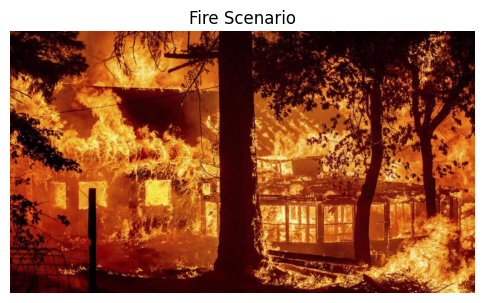

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("/content/fireimage.jpeg").convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Fire Scenario")
plt.show()

In [29]:
# FIRE SCENARIO - GENERATE IMAGE CAPTION USING BLIP

fire_inputs = processor(image, return_tensors="pt").to(device)
fire_output = blip_model.generate(
    **fire_inputs,
    max_new_tokens=50
)

fire_caption = processor.decode(
    fire_output[0],
    skip_special_tokens=True
)

print("Fire Image Caption:")
print(fire_caption)

Fire Image Caption:
a house is engulfed by fire


In [30]:
# FIRE SCENARIO - MULTIMODAL INTEGRATION WITH QWEN

fire_manual_report = """
Warehouse fire reported. Thick smoke may create breathing risk.
Workers are evacuating and fire service support is urgently required.
"""

fire_combined_report = f"""
Whisper Transcript:
{fire_result["text"]}

BLIP Image Caption:
{fire_caption}

Manual Text Report:
{fire_manual_report}
"""

In [31]:
def run_emergency_assessment(report):

    prompt = f"""
Emergency Incident:

{report}

Answer in EXACTLY four lines:

Incident Summary:
Severity Level:
Priority Recommendation:
Reasoning:

Do not repeat information.
Do not create lists.
Do not generate multiple severity levels.
Choose only ONE severity level.
"""

    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI disaster triage decision-support assistant. "
                "Use only the incident evidence provided. "
                "Do not invent facts."
            )
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    formatted_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = llm_tokenizer(
        formatted_prompt,
        return_tensors="pt"
    ).to(llm_model.device)

    outputs = llm_model.generate(
        **inputs,
        max_new_tokens=220,
        do_sample=False,
        pad_token_id=llm_tokenizer.eos_token_id
    )

    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]

    response = llm_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    # Run the same validation checks used by the main pipeline, so this
    # fire-scenario demo is held to the same standard rather than having
    # no safety net at all.
    validation = validate_assessment(response)
    print("Validation check:", "VALID" if validation["valid"] else "INVALID")
    if not validation["valid"]:
        print("Issues found:", validation["issues"])

    return response

In [32]:
# TEST STRUCTURED PROMPT ON FIRE SCENARIO

fire_structured_answer = run_emergency_assessment(fire_combined_report)

print("FIRE SCENARIO STRUCTURED ASSESSMENT:")
print(fire_structured_answer)

Validation check: INVALID
Issues found: ['Severity Level must be exactly one of: Low, Medium, High, Critical.']
FIRE SCENARIO STRUCTURED ASSESSMENT:
**Incident Summary:**
A warehouse fire has erupted, creating thick smoke that poses a significant health hazard to those inside. Workers have already begun evacuating the premises under emergency conditions.

**Severity Level:** Severe

**Priority Recommendation:** Immediate deployment of fire services for immediate containment and extinguishment of the blaze. Additionally, evacuation routes should be secured to prevent further spread of the fire and ensure public safety.

**Reasoning:** The presence of thick smoke indicates a high risk to human life due to inhalation hazards. Evacuation efforts suggest there are people trapped or at risk within the building. Fire suppression is crucial to mitigate potential structural damage and protect property from loss.


##Earthquake Scenario

In [ ]:
from gtts import gTTS
from IPython.display import Audio

earthquake_script = """
There has been a strong earthquake in the city centre.
A residential building has partially collapsed.
Several people may be trapped inside.
There are reports of serious injuries and damaged power lines.
Emergency rescue teams are urgently needed.
"""

tts = gTTS(earthquake_script)
tts.save("earthquake_audio.mp3")

print("Earthquake emergency audio created successfully.")
Audio("earthquake_audio.mp3")

Earthquake emergency audio created successfully.


In [ ]:
earthquake_result = model.transcribe("earthquake_audio.mp3")
earthquake_transcript = earthquake_result["text"]

print("Earthquake Audio Transcript:")
print(earthquake_transcript)

/usr/local/lib/python3.13/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


Earthquake Audio Transcript:
 There has been a strong earthquake in the city center. A residential building has partially collapsed. Several people may be trapped inside. There are reports of serious injuries and damaged power lines. Emergency rescue teams are urgently needed.


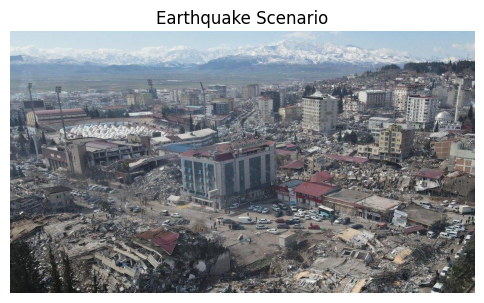

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load earthquake image directly from the Colab Files panel
earthquake_image = Image.open("/content/earthquake.jpg").convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(earthquake_image)
plt.axis("off")
plt.title("Earthquake Scenario")
plt.show()

In [ ]:
inputs = processor(earthquake_image, return_tensors="pt").to(device)

output = blip_model.generate(
    **inputs,
    max_new_tokens=50
)

earthquake_caption = processor.decode(output[0], skip_special_tokens=True)

print("Earthquake Image Caption:")
print(earthquake_caption)

Earthquake Image Caption:
a view of the destroyed city of kabul


In [ ]:
earthquake_manual_report = """
A strong earthquake has affected a residential area.
Several buildings have structural damage and one building has partially collapsed.
Residents report that people may be trapped under rubble.
Road access is blocked and aftershocks are possible.
"""

In [ ]:
earthquake_combined_input = f"""
Audio Transcript:
{earthquake_transcript}

Image Caption:
{earthquake_caption}

Manual Incident Report:
{earthquake_manual_report}
"""

print("Combined Earthquake Input:")
print(earthquake_combined_input)

Combined Earthquake Input:

Audio Transcript:
 There has been a strong earthquake in the city center. A residential building has partially collapsed. Several people may be trapped inside. There are reports of serious injuries and damaged power lines. Emergency rescue teams are urgently needed.

Image Caption:
a view of the destroyed city of kabul

Manual Incident Report:

A strong earthquake has affected a residential area.
Several buildings have structural damage and one building has partially collapsed.
Residents report that people may be trapped under rubble.
Road access is blocked and aftershocks are possible.




In [ ]:
earthquake_prompt = f"""
You are an emergency response decision-support assistant.

Use the information below to produce a short emergency assessment.

Audio: {earthquake_transcript}

Image: {earthquake_caption}

Report: {earthquake_manual_report}

Write the answer exactly like this:

Incident Summary: one short sentence
Severity Level: Low, Medium, High, or Critical
Priority Recommendation: one short sentence
Reasoning: one short sentence explaining why
"""

In [ ]:
messages = [
    {
        "role": "system",
        "content": (
            "You are an AI disaster triage decision-support assistant. "
            "Use only the incident evidence provided. "
            "Do not invent facts."
        )
    },
    {
        "role": "user",
        "content": earthquake_prompt
    }
]

formatted_prompt = llm_tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = llm_tokenizer(
    formatted_prompt,
    return_tensors="pt"
).to(llm_model.device)

outputs = llm_model.generate(
    **inputs,
    **GENERATION_CONFIG,
    pad_token_id=llm_tokenizer.eos_token_id,
    eos_token_id=llm_tokenizer.eos_token_id
)

input_length = inputs["input_ids"].shape[1]
generated_tokens = outputs[0][input_length:]

earthquake_answer = llm_tokenizer.decode(
    generated_tokens,
    skip_special_tokens=True
).strip()

validation = validate_assessment(earthquake_answer)
print("Validation check:", "VALID" if validation["valid"] else "INVALID")
if not validation["valid"]:
    print("Issues found:", validation["issues"])

print("Earthquake Emergency Assessment:")
print(earthquake_answer)

Validation check: INVALID
Issues found: ['Missing required field: Incident Summary:', 'Incident Summary is empty or could not be extracted.']
Earthquake Emergency Assessment:
**Incident Summation:** Residential building collapse due to earthquake, with potential for multiple casualties; critical situation requiring immediate emergency services deployment.

**Severity Level:** Critical

**Priority Recommendation:** Immediate dispatch of emergency rescue teams to assess and begin rescue operations.

**Reasoning:** The severity level is set as critical because there's a risk of significant loss of life from potentially trapped individuals or those injured during the quake. The priority recommendation ensures swift action by first responders to address the urgent need for rescuing victims and stabilizing the scene before further damage occurs.


## Scenario Output Summary

The table below summarises the AI models used for each simulated disaster scenario and demonstrates how multimodal information is processed to generate a structured emergency assessment.

| Scenario      | Audio Model | Image Model | Language Model | Final Output                                                         |
| ------------- | ----------- | ----------- | -------------- | -------------------------------------------------------------------- |
| Flood      | Whisper     | BLIP        | Qwen2.5-1.5B      | Incident Summary, Severity Level, Priority Recommendation, Reasoning |
| Fire       | Whisper     | BLIP        | Qwen2.5-1.5B      | Incident Summary, Severity Level, Priority Recommendation, Reasoning |
| Earthquake | Whisper     | BLIP        | Qwen2.5-1.5B      | Incident Summary, Severity Level, Priority Recommendation, Reasoning |

**Overall Workflow**

**Emergency Audio** → **Whisper** → Audio Transcript

**Disaster Image** → **BLIP** → Image Caption

**Manual Incident Report** → Combined with Transcript and Caption

**Combined Multimodal Information** → **Qwen2.5-1.5B** → Structured Emergency Assessment
